**Dynamic Optimization**

April 22, 2026


In [19]:
using LinearAlgebra
using Plots


Lotka-Volterra population dynamics model
$$\begin{align*}
\dot{x}_1(t) &= x_1(t)(p_1-x_2(t)),\qquad t\in[t_0,t_\text{f}] \\
\dot{x}_2(t) &= -x_2(t)(p_2-x_1(t)), \\
x_1(t_0) &= s_{0,1} \\
x_2(t_0) &= s_{0,2} \\
\end{align*}$$

In [20]:
NX = 2
NP = 2

function lotka_f(t::Float64, x::Vector{Float64}, p::Vector{Float64})
    return [
         x[1] * (p[1] - x[2]),
        -x[2] * (p[2] - x[1])
    ]
end

lotka_f (generic function with 1 method)

**Numerical solution of initial value problems using Runge-Kutta methods**



 The Butcher tableau of a Runge Kutta method is encoded in members a, b, c of structured variable of type `ButcherTableau`, so we can easily swap methods.
 This is not efficient as `a` and `b1`, `b2` may have some zeros that are not properly taken advantage of.

In [21]:
struct ButcherTableau
    a::Matrix{Float64}
    b1::Vector{Float64}
    b2::Vector{Float64}
    c::Vector{Float64}
    o::Int64
end

A fixed-step Runge-Kutta method using the tableau members `a`, `b1`, and `c` is easily implemented.
We record the entire trajectory in `traj`, and the number of steps and function evaluations in `n_steps` and `n_evals`.
The sums for forming the stage evaluation points `y_jj` and the iterates `eta` are realized using a matrix-vector multiplication and a dot product.

In [22]:
# A fixed-stepsize Runge Kutta method, given a Tableau, that solves the initial value problem
# x' = f(t,x) on t in [t0,tf]
function runge_kutta(
    f::Function, x0::Vector{Float64}, t0::Float64, tf::Float64, h::Float64, BT::ButcherTableau)
    # dimensions and allocation of variables
    dim_s = size(BT.c,1)
    dim_x = size(x0,1)
    k = zeros(dim_s, dim_x)
    # initial values
    t = t0
    eta = x0
    # book keeping
    n_steps = Int64(1+ceil((tf-t0)/h))
    n_evals = 0
    traj = zeros(dim_x,n_steps)
    n_steps = 0
    # the time stepping loop starts here
    while tf-t > 1e-4*h
        # step size h, but step onto final time tf if reachable
        h = min(tf-t, h)
        # evaluate s stages k_j = f(t + h*c_j, y_j)
        #                in y_j = eta + h*sum(a_jl, k_l over l = 1 .. j-1)
        for jj in 1:dim_s
            y_jj = eta + h * (k[1:jj-1,:]' * BT.a[jj,1:jj-1])
            k[jj,:] = f(t + h*BT.c[jj], y_jj)
        end
        # advance eta and t
        eta += h * (k' * BT.b1)
        t += h
        # book keeping
        n_steps += 1
        n_evals += dim_s
        traj[:,n_steps] = eta      # careful here: don't just append, but preallocate everything!
    end
    traj = traj[:,1:n_steps]
    return traj, n_steps, n_evals
end

runge_kutta (generic function with 1 method)

A simple Runge-Kutta method of fourth order with fixed step size is sufficient for this simple model. 
A more efficient implementation should exploit zeros in the tableau.

In [24]:
# The classic 4th order method by Runge and Kutta (1904)
RK4 = ButcherTableau(
    [  0    0  0  0
     1/2    0  0  0
       0  1/2  0  0
       0    0  1  0],
    [1/6, 1/3, 1/3, 1/6],
    [0.0],
    [0, 1/2, 1/2, 1],
    4
);

In [38]:
traj, _, _ = runge_kutta(
    (t,x)->lotka_f(t,x,[0.5,0.1]), 
    [1.0,1.0], 
    0.0, 100.0, 
    5e-2, 
    RK4
)

([0.9742073421777483 0.9469147841285944 … 0.6265289098533462 0.6396888267600217; 1.0453603969460303 1.0913284595584554 … 0.08314793922332017 0.08539401542980003], 2000, 8000)

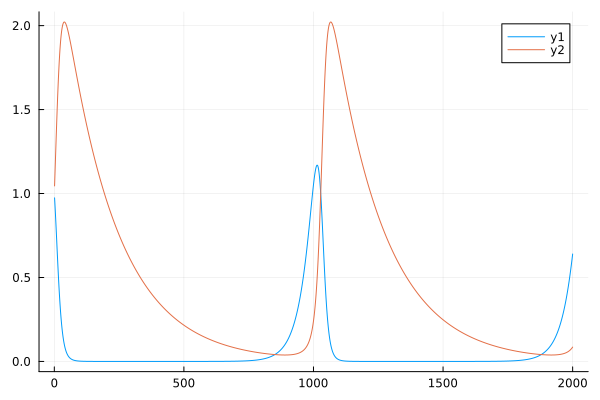

In [39]:
plot(traj[1,:])
plot!(traj[2,:])

How accurate are the solutions for a given step size? We don't have an analytic solution at hand, but can use a small-stepsize solution as a reference and observe **self-convergence** of the method.

In [40]:
# This does 20M steps and takes ~30 seconds on my M1Pro but only 7 seconds on my M4
ref_traj, _, _ = runge_kutta(
    (t,x)->lotka_f(t,x,[0.9,1.0]), 
    [1.0,1.0], 
    0.0, 20.0, 
    10 ^ -6, 
    RK4
)
println(ref_traj[:,end])

[0.988813997229775, 0.999367862710581]


If we solve the IVP using successively smaller step sizes $h=2^{-k}$ for $0 \leq k \leq 10$, we can experimentally verify the order of the method
by computing the quotient of global errors. Again we use the reference trajectory in place of the exact solution.
We find the order of the method to be between $log_2(14)$ and $log_2(16)=4$ in this run; the theoretical order is $4$.
The analysis of course breaks down as we close in on the precision of the reference trajectory.

In [41]:
err_prev=1
for hexp = 0:-1:-10
    traj, n_steps, n_evals = runge_kutta(
        (t,x)->lotka_f(t,x,[0.9,1.0]), 
        [1.0,1.0], 
        0.0, 20.0, 
        2.0 ^ hexp, 
        RK4
    )
    err = norm(traj[:,end] - ref_traj[:,end])

    print("h=$(2.0^hexp) steps=$n_steps err=$err")
    if hexp<0 print(" factor=$(err_prev/err)") end
    println()

    err_prev=err
end

h=1.0 steps=20 err=0.012699729967061145
h=0.5 steps=40 err=0.0008319047990463094 factor=15.265845300592131
h=0.25 steps=80 err=5.2044231746422025e-5 factor=15.984572567035766
h=0.125 steps=160 err=3.250258001860658e-6 factor=16.012338625619424
h=0.0625 steps=320 err=2.0312823651627743e-7 factor=16.00101520893282
h=0.03125 steps=640 err=1.279440636205296e-8 factor=15.876331481758875
h=0.015625 steps=1280 err=9.024967413005932e-10 factor=14.176678736385094
h=0.0078125 steps=2560 err=1.5939246183023107e-10 factor=5.662104286097561
h=0.00390625 steps=5120 err=1.1294556166444158e-10 factor=1.411232628191111
h=0.001953125 steps=10240 err=1.1003974385551601e-10 factor=1.0264069844868138
h=0.0009765625 steps=20480 err=1.0985981199073416e-10 factor=1.0016378315374963


Fehlberg (1978) realized that two Runge-Kutta methods of different orders could be used to (asymptotically for $h\to 0$) predict the lower order method's error:
$$O(h)\ni||\eta^{(k)}_{RK5}-\eta^{(k)}_{RK4}||=||\eta^{(k)}_{RK5}-x(t^{(k)})+x(t^{(k)})-\eta^{(k)}_{RK4}||\leq \underbrace{||\eta^{(k)}_{RK5}-x(t^{(k)})||}_{\in O(h^5)}+||\eta^{(k)}_{RK4}-x(t^{(k)})||\in O(h^4).$$

In [43]:
# A Fehlberg type Runge Kutta method, given a Tableau, that solves the initial value problem
# x' = f(t,x) on t in [t0,tf]
function runge_kutta_fehlberg(
    f::Function, x0::Vector{Float64}, t0::Float64, tf::Float64, 
    hmin::Float64, hmax::Float64, rel_tol::Float64, BT::ButcherTableau)
    # dimensions and allocation of variables
    dim_s = size(BT.c,1)
    dim_x = size(x0,1)
    k = zeros(dim_s, dim_x)
    # initial values
    t = t0
    eta = x0
    h = max(hmin, min(hmax, tf-t))
    # book keeping
    n_steps = Int64(1+ceil((tf-t0)/h))
    n_evals = 0
    x_traj = zeros(dim_x,n_steps)
    t_traj = zeros(n_steps)
    n_steps = 0
    n_reject = 0
    max_steps = 500000
    # the time stepping loop starts here
    while tf-t > 1e-4*h
        # step size h, but step onto final time tf if reachable
        h = min(tf-t, h)
    
        err_est = rel_tol
        while err_est >= rel_tol
            # evaluate s stages k_j = f(t + h*c_j, y_j)
            #                in y_j = eta + h*sum(a_jl, k_l over l = 1 .. j-1)
            for jj in 1:dim_s
                y_jj = eta + h * (k[1:jj-1,:]' * BT.a[jj,1:jj-1])
                k[jj,:] = f(t + h*BT.c[jj], y_jj)
            end
            n_evals += dim_s
            # error estimate
            err_est = h * norm(k' * (BT.b1-BT.b2), Inf)
            if err_est >= rel_tol / max(1, norm(eta, Inf))
                n_reject += 1
                h = 0.25 * h
                if h < hmin
                    println("The step size has become too small. Is f sufficiently smooth?")
                    return nothing
                end
            end
        end
                # advance eta and t
        eta += h * (k' * BT.b1)
        t += h        
        # new step size
        h = min(hmax, tf - t, 0.9 * h * (rel_tol / err_est) ^ (1/BT.o))
        # book keeping
        n_steps += 1
        if n_steps > max_steps
            println("Maximum number of steps reached, t=$t, h=$h, err_est=$err_est, rel_tol=$rel_tol, factor=$((rel_tol / err_est) ^ (1/(BT.o-1)))")
            return t_traj, nothing, n_steps, n_reject, n_evals
        end
        if size(t_traj,1) < n_steps    
            n_further = h > 0 ? Int64(1+ceil((tf-t)/h)) : 1
            x_traj = hcat(x_traj, zeros(dim_x,n_further))
            t_traj = vcat(t_traj, zeros(n_further))
        end
        x_traj[:,n_steps] = eta
        t_traj[n_steps] = t
    end
    x_traj = x_traj[:,1:n_steps]
    t_traj = t_traj[1:n_steps]
    return t_traj, x_traj, n_steps, n_reject, n_evals
end

runge_kutta_fehlberg (generic function with 1 method)

Getting so-called embedded method of neighboring order requires more function evaluations and leads to more involved solutions of the nonlinear system that cancels Taylor expansion terms. Below is Fehlberg's 1978 method of orders 4 and 5.

In [46]:
# Fehlbergs 1978 embedded Runge-Kutta method of orders 4 and 5
RKF45 = ButcherTableau(
    [   0         0           0         0        0       0
       1/4        0           0         0        0       0
       3/32       9/32        0         0        0       0
    1932/2197 -7200/2197   7296/2197    0        0       0
     439/216     -8        3680/513  -845/4104   0       0
      -8/27       2       -3544/2565 1859/4104 -11/40    0],
    [16/135,0, 6656/12825,28561/56430, -9/50,    2/55],   # order 5 step
    [25/216,0, 1408/2565,  2197/4104,  -1/5,     0   ],   # order 4 step
    [0, 1/4, 3/8, 12/13, 1, 1/2],
    5
);

If we let it run, it ensures a relative per-step error of less than $10^{-6}$ by making roughly $20,000$ steps with varying step sizes. The step size control appears to work fine with only a few rejections.

In [47]:
ref_ttraj, ref_xtraj, n_steps, n_reject, n_fevals = runge_kutta_fehlberg(
    (t,x)->lotka_f(t,x,[0.9,0.3]), 
    [1.0,1.0], 
    0.0, 20.0, 
    1e-12, 1.0, 
    1e-8,
    RKF45
)
println("$n_steps accepted, $n_reject rejected, $n_fevals f evaluations")

197 accepted, 59 rejected, 1230 f evaluations


The step sizes vary significantly and match the state evolution's perceived dynamics.

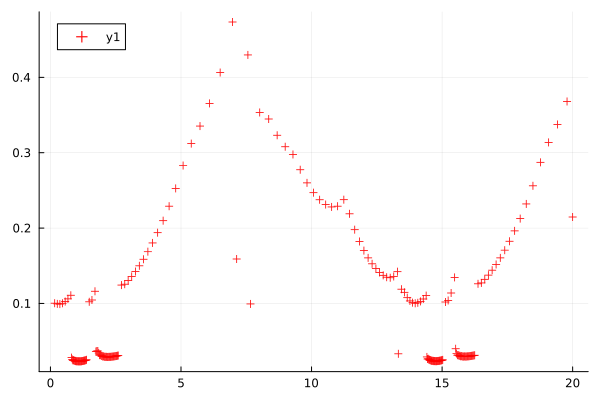

In [48]:
scatter(ref_ttraj[2:end],ref_ttraj[2:end]-ref_ttraj[1:end-1],markershape=:plus,markersize=4,markercolor=:red)

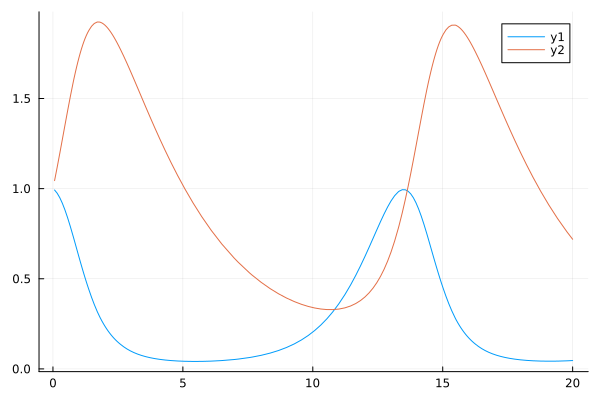

In [49]:
plot(ref_ttraj,ref_xtraj[1,:])
plot!(ref_ttraj,ref_xtraj[2,:])

We can repeat this at various tolerances. The order of the method isn't visible any more just by looking at the number of steps taken. Overall, the method is dramatically faster than the fixed-stepsize variants.

In [50]:
for tolexp in -2:-1:-12
    ref_ttraj, ref_xtraj, n_steps, n_reject, n_fevals = runge_kutta_fehlberg(
        (t,x)->lotka_f(t,x,[0.9,0.3]), 
        [1.0,1.0], 
        0.0, 20.0, 
        1e-6, 1.0, 
        10.0^tolexp,
        RKF45
    )
    println("At reltol=$(10.0^tolexp) n_steps=$n_steps, n_reject=$n_reject, n_fevals=$n_fevals")
end

At reltol=0.010000000000000002 n_steps=20, n_reject=0, n_fevals=120
At reltol=0.001 n_steps=22, n_reject=1, n_fevals=132
At reltol=0.0001 n_steps=33, n_reject=8, n_fevals=228
At reltol=1.0e-5 n_steps=47, n_reject=14, n_fevals=330
At reltol=1.0e-6 n_steps=76, n_reject=24, n_fevals=510
At reltol=1.0e-7 n_steps=123, n_reject=39, n_fevals=804
At reltol=1.0e-8 n_steps=197, n_reject=59, n_fevals=1230
At reltol=1.0e-9 n_steps=327, n_reject=101, n_fevals=2004
At reltol=1.0e-10 n_steps=537, n_reject=170, n_fevals=3252
At reltol=1.0e-11 n_steps=869, n_reject=280, n_fevals=5238
At reltol=1.0e-12 n_steps=1362, n_reject=433, n_fevals=8196
